# Labelled science phrases: building the D2 candidate-phrase dataset

This notebook demonstrates `data.py` from the **"Labelled science phrases and new-term pool"** dataset artifact
(emerging-concepts study). In the original run, `data.py` converts the prepared inputs into the
`exp_sel_data_out` schema. Its output is seven datasets (D1–D6), one group per dataset and one example per row.

The demo runs the core builder, **D2 `llm_labelled_candidate_phrases`**. The keys are noun phrases and acronym long forms
mined from OpenAlex abstracts with spaCy and Schwartz–Hearst. Three LLMs labelled each key
**CONCEPT / NOT_CONCEPT / TOO_GENERIC / VARIANT_OF**:

* **A** = `google/gemini-2.5-flash-lite`, **B** = `openai/gpt-4.1-nano` (independent labellers)
* an **adjudicator** `anthropic/claude-haiku-4.5`, which labelled every A≠B item and a 200-item "silver gold" audit set

`d2_labels()` merges the three label sources into one final label per key and records the basis for each label
(adjudicator, A/B consensus or unresolved). It then assigns the fold (train/test, split by variant cluster, or pool_screen)
and builds a stratum string and a key-quality flag.

**Demo data.** `mini_demo_data.json` is a stratified subset of **100 keys** from the four raw labelling files
(`items.json`, `labels_AB.json`, `labels_adj.json`, `split.json`), in the same shapes `data.py` reads.
It covers every combination of fold, track, final label and label basis. The full dataset has 4,599 keys:
1,200 train, 300 test and 3,099 pool_screen.

*The labels are LLM-adjudicated silver labels, and no human has checked them.*

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, numpy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports

This is the original import block of `data.py`. There are two notebook-only changes:
* `ROOT = Path(__file__)...` becomes the current working directory, because notebooks have no `__file__`.
* The two local helper modules (`scripts/textnorm.py`, `scripts/rawio.py`) are commented out. They are only used by D1 (`read_corpus_works`)
  and D4b (`schwartz_hearst`), which need the full raw corpus and are not run here.

Plotting and table imports for the final results cell are added at the bottom.

In [2]:
from __future__ import annotations

import argparse
import ast
import json
import sys
from pathlib import Path

from loguru import logger

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
# sys.path.insert(0, str(ROOT / "scripts"))
# from textnorm import schwartz_hearst  # noqa: E402   (only used by D4b, not run in this demo)
# from rawio import read_corpus_works  # noqa: E402    (only used by D1, not run in this demo)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

LAB = ROOT / "labelling"
TD = ROOT / "temp" / "datasets"

# --- notebook additions (results / visualisation) ---
import time
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix

## Load the demo data

The data comes from the GitHub repository when it is reachable (for example on Colab). Otherwise it falls back to the local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_F1tk5OGtH84L/round-1/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("keys in demo data:", len(data["items"]))
print("A labels:", len(data["labels_AB"]["A"]), "| B labels:", len(data["labels_AB"]["B"]),
      "| adjudicated:", len(data["labels_adj"]["labels"]), "| in silver_gold_200:", len(data["labels_adj"]["silver_gold_200"]))
print("track counts:", dict(Counter(v["track"] for v in data["items"].values())))

Stratified 100-key subset of the raw D2 labelling inputs consumed by data.py::d2_labels()
keys in demo data: 100
A labels: 100 | B labels: 100 | adjudicated: 50 | in silver_gold_200: 24
track counts: {'L': 45, 'L_nonnovel': 39, 'P': 16}


## Configuration

The script itself has no training loop. The only size knob is **how many candidate keys** `d2_labels()` processes.
The original run used all **4,599** keys from the full labelling files. The demo processes up to the 100 keys in `mini_demo_data.json`.
Processing is pure-Python dict work and takes milliseconds, so the demo uses all 100.

In [5]:
N_KEYS = 100          # keys (sorted) taken from the demo subset; demo max = 100, original full run = 4599
OUT_PATH = ROOT / "demo_data_out.json"   # original: --out default ROOT / "full_data_out.json"

## Helpers: JSONL reader, key-quality flag and string coercion

These are unchanged from `data.py`. `key_quality()` flags known extraction defects: keys that start with punctuation or a
non-Latin symbol, and keys containing publisher boilerplate such as "© Elsevier". The flagged keys are kept in the data
(the normaliser was deliberately left unchanged so outputs stay reproducible), so later steps can filter on this flag.
`s()` makes sure `input`/`output` are always strings, as the schema requires.

In [6]:
def jl(p: Path):
    with p.open() as f:
        for line in f:
            if line.strip():
                yield json.loads(line)


KEY_OK = __import__("re").compile(r"^[a-z0-9α-ω]")
BOILER = ("©", "wiley periodical", "all rights reserved", "elsevier")


def key_quality(k: str) -> str:
    """Known extraction defect flag (documented in README): keys that start with punctuation/symbols,
    non-Latin script or publisher boilerplate. The normaliser is left unchanged so outputs stay reproducible."""
    if any(b in k for b in BOILER):
        return "boilerplate"
    if not KEY_OK.match(k):
        return "malformed_leading_char"
    return "ok"


def s(x) -> str:
    return x if isinstance(x, str) else json.dumps(x, ensure_ascii=False)

## D1 builder: OpenAlex stratified corpus (definition only)

This builder is copied unchanged for reference and **is not run** in the demo. It needs the 93,600-work corpus
(`raw/corpus_works/*.jsonl`) and `raw/strata.json`. Each abstract is paired with its primary field, the stratum
(field × year) and the design weight `N_stratum / n_sampled`.

In [7]:
# ---------------------------------------------------------------- D1
def d1_corpus(limit: int | None = None) -> list[dict]:
    strata = json.loads((ROOT / "raw" / "strata.json").read_text())
    w = {(x["field_id"], x["year"], x["corpus"]): x for x in strata["strata"]}
    out = []
    for i, r in enumerate(read_corpus_works()):
        if limit and i >= limit:
            break
        st = w[(r["stratum_field"], r["stratum_year"], r["corpus"])]
        out.append({
            "input": ((r["title"] or "").strip() + " " + (r["abstract"] or "")).strip(),
            # the corpus is a text source, not a labelled set; output carries the OpenAlex primary field (stratum label)
            "output": r["field"] or "",
            "metadata_fold": f"corpus_{r['corpus']}",
            "metadata_work_id": r["id"], "metadata_doi": r["doi"], "metadata_title": r["title"],
            "metadata_publication_year": r["year"], "metadata_publication_date": r["date"],
            "metadata_field_id": r["field_id"], "metadata_field": r["field"], "metadata_subfield_id": r["subfield_id"],
            "metadata_subfield": r["subfield"], "metadata_domain": r["domain"], "metadata_topic_id": r["topic_id"],
            "metadata_topic": r["topic"], "metadata_venue_id": r["venue_id"], "metadata_venue_type": r["venue_type"],
            "metadata_keywords": r["keywords"], "metadata_legacy_concepts_score_ge_0_3": r["concepts"],
            "metadata_referenced_works_count": r["referenced_works_count"], "metadata_author_ids": r["author_ids"],
            "metadata_institution_ids": r["institution_ids"],
            "metadata_stratum": f"field{r['stratum_field']}_{r['stratum_year']}_{r['corpus']}",
            "metadata_N_stratum": st["N_stratum"], "metadata_n_sampled_stratum": st["n_sampled"],
            "metadata_design_weight": st["design_weight"], "metadata_sample_seed": st["seed"],
        })
    return out

## D2 builder: LLM-labelled candidate phrases (run in this demo)

This is the core of the demo. For each key, the final label is chosen in this order:
1. The **adjudicator** label if one exists. Every A≠B item and every item in the 200-key silver-gold audit set has one.
2. Otherwise the **A/B consensus** label if the two labellers agree.
3. Otherwise `UNRESOLVED`. Test items that stay unresolved move to the `test_unresolved_excluded` fold.

`VARIANT_OF` labels carry the canonical key, for example `VARIANT_OF:<key>`. The stratum string is
`<frequency band>|<form>|<macro domain>`, where the form is `acronym`, `1tok`, `2tok` or `3+tok`.

**Only change from the original:** the first four lines read from the loaded `data` dict instead of
`labelling/*.json`, and the items are cut to `N_KEYS`.

In [8]:
# ---------------------------------------------------------------- D2
def band(n: int) -> str:
    return "3-5" if n <= 5 else "6-20" if n <= 20 else "21-100" if n <= 100 else ">100"


def d2_labels() -> list[dict]:
    items = data["items"]          # original: json.loads((LAB / "items.json").read_text())
    AB = data["labels_AB"]         # original: json.loads((LAB / "labels_AB.json").read_text())
    ADJ = data["labels_adj"]       # original: json.loads((LAB / "labels_adj.json").read_text())
    sp = data["split"]             # original: json.loads((LAB / "split.json").read_text())
    items = {k: items[k] for k in sorted(items)[:N_KEYS]}  # demo: limit to N_KEYS keys
    silver = set(ADJ["silver_gold_200"])
    adj = ADJ["labels"]
    out = []
    for k in sorted(items):
        it = items[k]
        a, b, j = AB["A"].get(k, {}), AB["B"].get(k, {}), adj.get(k, {})

        def fmt(r: dict) -> str | None:
            if not r.get("label"):
                return None
            return f"VARIANT_OF:{r['variant_of']}" if r["label"] == "VARIANT_OF" and r.get("variant_of") else r["label"]

        la, lb, lj = fmt(a), fmt(b), fmt(j)
        if lj:
            final, basis = lj, "adjudicator"
        elif la and la == lb:
            final, basis = la, "A/B consensus"
        else:
            final, basis = "UNRESOLVED", "A/B disagree, not adjudicated" if la and lb else "missing label"
        if it["track"] == "P":
            fold = "pool_screen"
        else:
            fold = sp["split"][k]
            if fold == "test" and final == "UNRESOLVED":
                fold = "test_unresolved_excluded"
        st = it["stats"]
        form = "acronym" if st["is_acronym_long_form"] else ("1tok" if st["n_tokens"] == 1 else "2tok" if st["n_tokens"] == 2 else "3+tok")
        inp = {"key": k, "surface_forms": it["surface_forms"],
               "acronym_short_forms": it.get("acronym_short_forms", []),
               "snippets": it["snippets"], "n_sample_occ": st["n_occ"],
               "first_sample_year": st["first_main_year"], "n_fields": st["n_fields"]}
        out.append({
            "input": s(inp), "output": final, "metadata_fold": fold,
            "metadata_track": {"L": "L_novel", "L_nonnovel": "L_nonnovel_supplement", "P": "P_pool_screen"}[it["track"]],
            "metadata_label_basis": basis, "metadata_silver_gold_200": k in silver,
            "metadata_label_A": la, "metadata_label_B": lb, "metadata_label_adj": lj,
            "metadata_rationale_A": a.get("rationale"), "metadata_rationale_B": b.get("rationale"),
            "metadata_rationale_adj": j.get("rationale"),
            "metadata_confidence_A": a.get("confidence"), "metadata_confidence_B": b.get("confidence"),
            "metadata_confidence_adj": j.get("confidence"),
            "metadata_model_A": a.get("model"), "metadata_model_B": b.get("model"), "metadata_model_adj": j.get("model"),
            "metadata_label_date": a.get("date") or b.get("date"),
            "metadata_batch_cost_usd_A": a.get("batch_cost"), "metadata_batch_cost_usd_B": b.get("batch_cost"),
            "metadata_variant_cluster": sp["cluster"].get(k),
            "metadata_stratum": f"{band(st['n_occ']) if st['n_occ'] >= 3 else str(st['n_occ'])}|{form}|{st['macro_domain']}",
            "metadata_macro_domain": st["macro_domain"], "metadata_cvalue": st["cvalue"],
            "metadata_in_prescreen_or_pre2005": st["in_pre"], "metadata_audit_arm": bool(it.get("audit_arm", False)),
            "metadata_key_quality": key_quality(k),
            "metadata_human_checked": False,
        })
    return out

## D3 to D6 and the extra candidate builders (definitions only)

These builders are copied unchanged for reference and are **not run** in the demo, because each one reads a different input file
from the original workspace:
* **D3** `variant_pairs`: SAME/DIFFERENT phrase pairs from `labelling/variant_pairs.json`.
* **D4a/D4b**: human-annotated anchors from SemEval-2017/SciERC phrases and SciAD acronym sentences.
  D4b stores our Schwartz–Hearst predictions next to the gold pairs.
* **D5**: the survivorship-free early phrase pool. The sealed full-count outcome file is never read.
* **D6**: the held-out phrase works.
* The `midas_*`, `kp20k` and `vocab` builders are only used when the script runs with `--all` to stage candidates.

In [9]:
# ---------------------------------------------------------------- D3
def d3_pairs() -> list[dict]:
    V = json.loads((LAB / "variant_pairs.json").read_text())
    out = []
    for p in V["pairs"]:
        out.append({
            "input": s({"phrase_1": p["phrase_1"], "phrase_2": p["phrase_2"], "context_1": p["context_1"], "context_2": p["context_2"]}),
            "output": p["final_label"], "metadata_fold": p["fold"], "metadata_source": p["source"],
            "metadata_gold_source": p["gold_source"], "metadata_label_basis": p["label_basis"],
            "metadata_curated_label": p["curated_label"], "metadata_llm_label_A": p["llm_label_A"],
            "metadata_llm_label_B": p["llm_label_B"], "metadata_llm_label_adj": p["llm_label_adj"],
            "metadata_key_1": p["key_1"], "metadata_key_2": p["key_2"], "metadata_cross_split": p["cross_split"],
            "metadata_cluster_1": p["cluster_1"], "metadata_cluster_2": p["cluster_2"],
        })
    return out


# ---------------------------------------------------------------- D4
def d4a_phrases(limit: int | None = None) -> list[dict]:
    an = json.loads((LAB / "anchor_labels.json").read_text())
    by_phrase = {}
    for k, h in an["items"].items():
        by_phrase[(h["source"], h["source_doc_id"], h["phrase"], h["label"], h.get("entity_type"))] = (an["llm"].get("A", {}).get(k, {}), an["llm"].get("B", {}).get(k, {}))
    out = []
    for i, r in enumerate(jl(ROOT / "raw" / "anchor_phrases.jsonl")):
        if limit and i >= limit:
            break
        la, lb = by_phrase.pop((r["source"], r["source_doc_id"], r["phrase"], r["label"], r.get("entity_type")), ({}, {}))
        out.append({
            "input": s({"phrase": r["phrase"], "sentence_context": r["sentence_context"], "source_doc_id": r["source_doc_id"]}),
            "output": r["label"], "metadata_fold": r["fold"], "metadata_source": r["source"],
            "metadata_entity_type": r.get("entity_type"),
            "metadata_label_origin": "human annotation" if r["label"] != "NOT_ANNOTATED" else "spaCy noun chunk overlapping no human-annotated span",
            "metadata_in_llm_anchor_check": bool(la or lb),
            "metadata_llm_label_A": la.get("label"), "metadata_llm_label_B": lb.get("label"),
        })
    return out


def d4b_acronyms(limit: int | None = None) -> list[dict]:
    out = []
    for i, r in enumerate(jl(ROOT / "raw" / "anchor_acronyms.jsonl")):
        if limit and i >= limit:
            break
        gold = json.loads(r["output"])
        pairs = [{"short_form": a, "long_form": b} for a, b in schwartz_hearst(r["input"])]
        out.append({"input": r["input"], "output": s({"short_forms": gold["short_forms"], "long_forms": gold["long_forms"]}),
                    "metadata_fold": r["fold"], "metadata_sentence_id": r["id"],
                    "metadata_source": "amirveyseh/acronym_identification (SciAD)",
                    "metadata_schwartz_hearst_pred": pairs})
    return out


# ---------------------------------------------------------------- D5
def d5_pool() -> list[dict]:
    pool = json.loads((ROOT / "data_out" / "pool_early.json").read_text())
    out = []
    for p in pool:
        inp = {"key": p["key"], "surface_forms": p["surface_forms"], "acronym_short_forms": p["acronym_short_forms"],
               "snippets": p["snippets"]}
        row = {"input": s(inp), "output": p["link_status"], "metadata_fold": "heldout_phrase"}
        for k, v in p.items():
            if k in ("key", "surface_forms", "acronym_short_forms", "snippets", "link_status"):
                continue
            row[f"metadata_{k}"] = v
        row["metadata_key"] = p["key"]
        row["metadata_key_quality"] = key_quality(p["key"])
        out.append(row)
    return out


# ---------------------------------------------------------------- D6
def d6_works() -> list[dict]:
    return json.loads((ROOT / "subsample" / "heldout_works_rows.json").read_text())


# ---------------------------------------------------------------- extra candidates (staged only)
def midas_keyphrases(repo: str, files: list[tuple[str, str]], limit: int) -> list[dict]:
    out = []
    for fn, fold in files:
        p = TD / repo / fn
        if not p.exists():
            continue
        for r in jl(p):
            doc = r["document"] if isinstance(r["document"], list) else ast.literal_eval(r["document"])
            kp = r.get("extractive_keyphrases")
            kp = kp if isinstance(kp, list) else ast.literal_eval(kp or "[]")
            ab = r.get("abstractive_keyphrases")
            ab = ab if isinstance(ab, list) else ast.literal_eval(ab or "[]")
            out.append({"input": " ".join(doc)[:4000], "output": s({"extractive": kp, "abstractive": ab}),
                        "metadata_fold": fold, "metadata_doc_id": str(r.get("id") or r.get("paper_id") or r.get("document_id") or ""), "metadata_source": repo})
            if len(out) >= limit:
                return out
    return out


def kp20k(limit: int) -> list[dict]:
    out = []
    for r in jl(TD / "taln-ls2n__kp20k" / "test.json"):
        out.append({"input": (r["title"] + ". " + r["abstract"])[:4000], "output": s(r.get("keyphrases")),
                    "metadata_fold": "test", "metadata_doc_id": r["id"], "metadata_prmu": r.get("prmu"),
                    "metadata_source": "taln-ls2n/kp20k"})
        if len(out) >= limit:
            break
    return out


def vocab(kind: str, limit: int) -> list[dict]:
    if kind == "mesh":
        rows = json.loads((TD / "mesh" / "mesh_descriptors_2026.json").read_text())[:limit]
        return [{"input": r["heading"], "output": s(r["entry_terms"]), "metadata_fold": "vocab", "metadata_ui": r["ui"],
                 "metadata_tree_numbers": r["tree_numbers"]} for r in rows]
    rows = json.loads((TD / "openalex_snapshot" / f"{kind}.json").read_text())[:limit]
    return [{"input": r["display_name"] or "", "output": r["id"], "metadata_fold": "vocab",
             **{f"metadata_{k}": v for k, v in r.items() if k not in ("display_name", "id")}} for r in rows]

## Dataset registry and schema check

`SELECTED` is the original registry of the seven deliverables. `check_rows()` enforces the `exp_sel_data_out` contract:
string `input`/`output`, and every other field must start with `metadata_`. `extra_candidates()` is unchanged but not called in the demo.

In [10]:
SELECTED = [
    ("openalex_stratified_corpus_2003_2016_with_prescreen_1995_2004", lambda: d1_corpus()),
    ("llm_labelled_candidate_phrases", d2_labels),
    ("variant_pairs", d3_pairs),
    ("external_human_anchors_semeval2017_scierc_phrases", lambda: d4a_phrases()),
    ("external_human_anchors_acronym_identification", lambda: d4b_acronyms()),
    ("survivorship_free_phrase_pool_early", d5_pool),
    ("heldout_phrase_works", d6_works),
]


def extra_candidates(n: int) -> list[tuple[str, callable]]:
    return [
        ("midas_inspec_keyphrases", lambda: midas_keyphrases("midas__inspec", [("train.jsonl", "train"), ("valid.jsonl", "validation"), ("test.jsonl", "test")], n)),
        ("midas_semeval2010_keyphrases", lambda: midas_keyphrases("midas__semeval2010", [("train.jsonl", "train"), ("test.jsonl", "test")], n)),
        ("midas_nus_keyphrases", lambda: midas_keyphrases("midas__nus", [("test.jsonl", "test")], n)),
        ("taln_ls2n_kp20k_test_keyphrases", lambda: kp20k(n)),
        ("openalex_keywords_vocabulary", lambda: vocab("keywords", n)),
        ("openalex_legacy_concepts_vocabulary", lambda: vocab("concepts", n)),
        ("nlm_mesh_2026_descriptors", lambda: vocab("mesh", n)),
    ]


def check_rows(name: str, rows: list[dict]) -> None:
    bad = 0
    for r in rows:
        if not isinstance(r.get("input"), str) or not isinstance(r.get("output"), str):
            bad += 1
        for k in r:
            if k not in ("input", "output") and not k.startswith("metadata_"):
                raise ValueError(f"{name}: illegal field {k}")
    if bad:
        raise ValueError(f"{name}: {bad} rows with non-string input/output")

## Main: build, validate and write the output

This is the default (non-`--all`) branch of the original `main()`. There are three notebook changes:
* argparse is replaced by `OUT_PATH` from the config cell.
* Only the D2 entry of `SELECTED` runs, because the other builders need the full workspace inputs.
* The `--all` staging branch is kept as a comment.

The metadata block is unchanged.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    # ap = argparse.ArgumentParser()
    # ap.add_argument("--all", action="store_true", help="stage all 14 candidates (<=200 rows each) into temp/")
    # ap.add_argument("--out", default=str(ROOT / "full_data_out.json"))
    # a = ap.parse_args()
    # if a.all: ... (stages d1_corpus(limit=200), the other SELECTED builders [:200] and extra_candidates(200)
    #               into temp/all14_candidates_data_out.json; not run in the demo)
    groups = []
    for name, fn in [x for x in SELECTED if x[0] == "llm_labelled_candidate_phrases"]:  # original: for name, fn in SELECTED:
        rows = fn()
        check_rows(name, rows)
        logger.info(f"{name}: {len(rows)} examples")
        groups.append({"dataset": name, "examples": rows})
    meta = {
        "artifact": "gen_plan_dataset_4_idx4: labelled concept phrases and survivorship-free phrase pool",
        "created": "2026-09-28",
        "sources": "OpenAlex API (sampled works, counts, works), OpenAlex S3 snapshot (keywords, concepts), NLM MeSH 2026, "
                   "Wikidata API, HF: midas/semeval2017, zj88zj/SCIERC, amirveyseh/acronym_identification",
        "label_status": "D2/D3 LLM labels are LLM-adjudicated SILVER labels; no human has checked them (human_checked=false).",
        "sealed_file": "data_out/pool_outcomes_SEALED.json holds the full yearly counts and is deliberately NOT included here.",
    }
    Path(OUT_PATH).write_text(json.dumps({"metadata": meta, "datasets": groups}, ensure_ascii=False))
    logger.info(f"wrote {OUT_PATH}")


t0 = time.time()
main()
print(f"main() took {time.time() - t0:.3f}s")

03:23:16|INFO   |llm_labelled_candidate_phrases: 100 examples


03:23:16|INFO   |wrote demo_data_out.json


main() took 0.041s


## Results

The cell reloads the written output and summarises the D2 rows. It shows:
* the final label × fold table and how each label was reached (label basis),
* how often labeller A and labeller B agree, with Cohen's κ over the rows where both labelled.
  On the full track-L set, κ≈0.26 in `labelling/quality.json`, because B over-labels CONCEPT,
* the adjudicator's agreement with A and B on the rows it labelled,
* a few example rows with their rationales.

The demo subset is **stratified** across fold, track, final label and label basis, so its label proportions are *not*
representative of the full dataset. The agreement numbers only show what the pipeline computes.

Dataset: llm_labelled_candidate_phrases  |  rows: 100
D2/D3 LLM labels are LLM-adjudicated SILVER labels; no human has checked them (human_checked=false). 

Final label x fold
metadata_fold  pool_screen  test  train  All
final_label                                 
CONCEPT                  5    18     16   39
NOT_CONCEPT              5    14     16   35
TOO_GENERIC              1     8     12   21
UNRESOLVED               5     0      0    5
All                     16    40     44  100 

Label basis x track
metadata_track                 L_nonnovel_supplement  L_novel  P_pool_screen  All
metadata_label_basis                                                             
A/B consensus                                     15       19             11   45
A/B disagree, not adjudicated                      0        0              5    5
adjudicator                                       24       26              0   50
All                                               39       45             16 

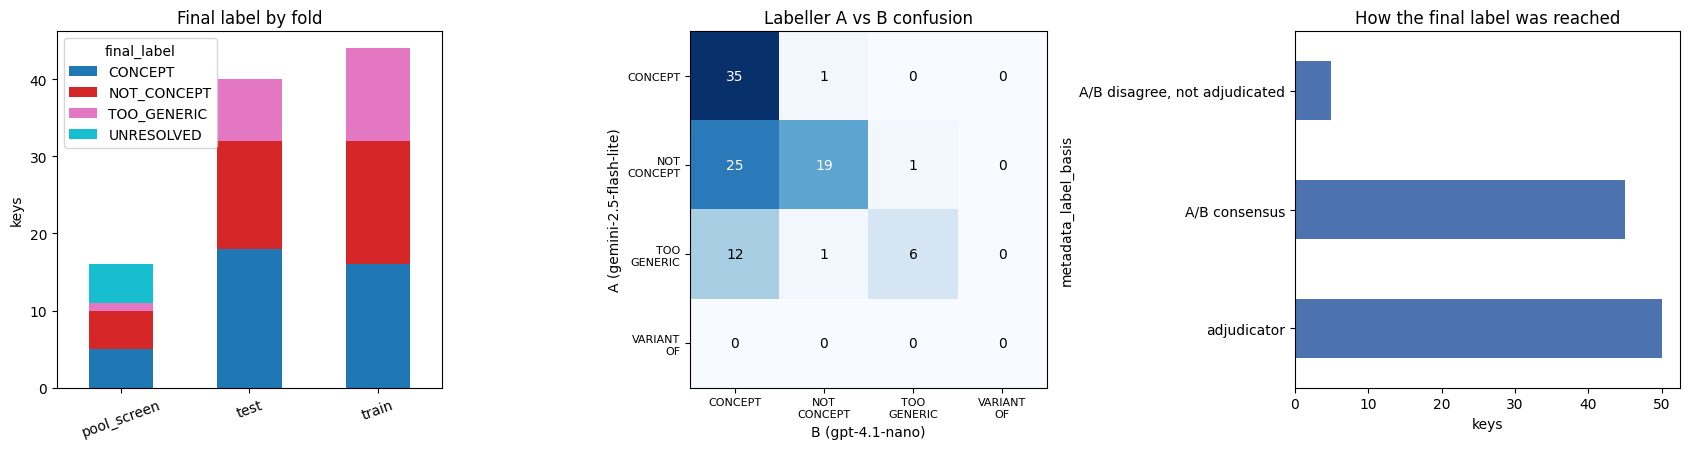


Example rows:
                                   key      output metadata_fold          metadata_label_basis metadata_label_A metadata_label_B metadata_label_adj                                                       metadata_rationale_adj      metadata_stratum
              above mentioned criteria NOT_CONCEPT          test                   adjudicator      NOT_CONCEPT      NOT_CONCEPT        NOT_CONCEPT Methodological filler phrase referring to study-specific selection criteria.      3-5|3+tok|health
                     adaptive response     CONCEPT          test                 A/B consensus          CONCEPT          CONCEPT               None                                                                         None 21-100|acronym|health
                               adipose TOO_GENERIC         train                   adjudicator      TOO_GENERIC          CONCEPT        TOO_GENERIC      Basic tissue type used across all biomedical research, too fundamental.         3-5|1tok|li

In [12]:
out = json.loads(Path(OUT_PATH).read_text())
rows = out["datasets"][0]["examples"]
df = pd.DataFrame(rows)
df["final_label"] = df["output"].str.replace(r"^VARIANT_OF:.*", "VARIANT_OF", regex=True)
print(f"Dataset: {out['datasets'][0]['dataset']}  |  rows: {len(df)}")
print(out["metadata"]["label_status"], "\n")

print("Final label x fold")
print(pd.crosstab(df["final_label"], df["metadata_fold"], margins=True).to_string(), "\n")
print("Label basis x track")
print(pd.crosstab(df["metadata_label_basis"], df["metadata_track"], margins=True).to_string(), "\n")
print("Key-quality flags:", dict(Counter(df["metadata_key_quality"])))

strip = lambda x: None if x is None else x.split(":")[0]
both = df.dropna(subset=["metadata_label_A", "metadata_label_B"])
la, lb = both["metadata_label_A"].map(strip), both["metadata_label_B"].map(strip)
LABELS = ["CONCEPT", "NOT_CONCEPT", "TOO_GENERIC", "VARIANT_OF"]
print(f"\nA vs B on {len(both)} rows: raw agreement {(la == lb).mean():.3f}, Cohen's kappa {cohen_kappa_score(la, lb, labels=LABELS):.3f}")
adj = df.dropna(subset=["metadata_label_adj"])
for m in ("A", "B"):
    sub = adj.dropna(subset=[f"metadata_label_{m}"])
    if len(sub):
        print(f"Adjudicator vs {m} on {len(sub)} adjudicated rows: agreement "
              f"{(sub[f'metadata_label_{m}'].map(strip) == sub['metadata_label_adj'].map(strip)).mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ct = pd.crosstab(df["metadata_fold"], df["final_label"])
ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Final label by fold"); axes[0].set_xlabel(""); axes[0].set_ylabel("keys"); axes[0].tick_params(axis="x", rotation=20)
cm = confusion_matrix(la, lb, labels=LABELS)
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(4), [l.replace("_", "\n") for l in LABELS], fontsize=8)
axes[1].set_yticks(range(4), [l.replace("_", "\n") for l in LABELS], fontsize=8)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[1].set_xlabel("B (gpt-4.1-nano)"); axes[1].set_ylabel("A (gemini-2.5-flash-lite)"); axes[1].set_title("Labeller A vs B confusion")
df["metadata_label_basis"].value_counts().plot(kind="barh", ax=axes[2], color="#4c72b0")
axes[2].set_title("How the final label was reached"); axes[2].set_xlabel("keys")
plt.tight_layout(); plt.show()

print("\nExample rows:")
show = df.groupby("final_label").head(2)[["input", "output", "metadata_fold", "metadata_label_basis",
                                           "metadata_label_A", "metadata_label_B", "metadata_label_adj", "metadata_rationale_adj", "metadata_stratum"]].copy()
show["input"] = show["input"].map(lambda x: json.loads(x)["key"])
show = show.rename(columns={"input": "key"})
with pd.option_context("display.max_colwidth", 60, "display.width", 250):
    print(show.to_string(index=False))